# 在 Colab 中打开
<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ai-agents-the-definitive-guide/blob/main/CH02/ch02_react.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>


# 关于这个 Notebook

这个 Notebook 集中演示如何使用 **LangGraph** 和 **LangChain OpenAI** 构建一个最小可用的 ReAct-style agent（ReAct 风格智能体），其中包含一个紧凑的互联网搜索工具和一条易读的 execution trace（执行轨迹）。你会看到如何把工具绑定到模型、如何在模型与工具之间路由，以及如何打印一份符合 ReAct action-observation-final answer（行动—观察—最终答案）模式的清晰执行记录。

## 它展示了什么

* **Typed agent state（类型化智能体状态）**：使用 `add_messages` reducer（归约器）累积 `messages`。
* **Tool binding（工具绑定）**：把一个由 SerpAPI 支持、返回紧凑 JSON 的 `internet_search` 工具绑定到模型。
* **双节点图（two-node graph）**

  1. `agent` 节点：调用带 system prompt 的模型
  2. `tools` 节点：执行待处理的工具调用，并返回 `ToolMessage` 输出。
* **Conditional routing（条件路由）**：模型 → 工具 → 模型循环执行，直到不再存在工具调用，然后结束。
* **ReAct-style tracing（ReAct 风格轨迹）**：`print_react_trace(question)` 会打印简短的推理摘要、工具动作、观察结果和最终答案。
* **可选图预览**：使用 Mermaid PNG 渲染图结构。

## 你将运行什么

1. 安装一个小型依赖栈：`langgraph`、`langchain-openai`、`python-dotenv` 和 `google-search-results`。
2. 从 `.env` 加载环境变量并验证 `OPENAI_API_KEY`；实时搜索使用 `SERPAPI_API_KEY`。
3. 定义 `internet_search` 工具，通过 SerpAPI 查询 Google，并以 JSON 返回排名靠前的结果。
4. 构建并编译包含 `agent` 与 `tools` 两个节点、以 `END` 为终止条件的 **StateGraph**。
5. 调用 `print_react_trace("What is the weather in Zurich today?")`，观察完整循环和最终回复。
6. 可选地使用 Mermaid 渲染图结构。

## 它如何工作

* **System prompt（系统提示词）**要求助手保持工具调用简洁，并在结束时给出清晰的最终答案。
* **Agent node（智能体节点）**在 `[SYSTEM_PROMPT] + state["messages"]` 上调用模型。
* **Tools node（工具节点）**检查 `last.tool_calls`，按名称执行每个工具，并把 JSON payload（载荷）封装为 `ToolMessage`。
* **Router（路由器）**函数 `should_continue`：存在工具调用时返回 `"continue"`，否则返回 `"end"`。

## 为什么采用这种模式

* ReAct 风格智能体的控制逻辑容易理解。Notebook 展示的是可读执行轨迹，而不是暴露 chain of thought（思维链）。
* LangGraph 让控制流保持显式，因此 transition function（转换函数）非常容易阅读和测试。
* 工具输出统一规范为 JSON，使模型能解析结构一致的观察结果。

## 如何扩展与调整

* 增加更多工具，并将它们加入 `TOOLS` 和 `TOOLS_BY_NAME`。
* 用其他返回 JSON 的搜索后端替换 SerpAPI。
* 用 checkpointer（检查点保存器）替换默认的内存行为，实现持久化记忆。
* 如果需要更可靠的 grounded outputs（有依据输出），可在最终答案之前增加验证或摘要节点。

## 运行要求与说明

* 必须提供 `OPENAI_API_KEY`；实时搜索还需要 `SERPAPI_API_KEY`。
* 互联网结果会随时间变化，不同日期运行可能得到不同摘要与答案。
* Mermaid 渲染可能需要额外依赖；图预览是可选功能。


# 依赖项

In [1]:
!pip install -qqq langgraph==1.1.2 langchain-openai==1.1.11 python-dotenv==1.1.1 google-search-results==2.4.2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.3.4 requires langgraph<1.3.0,>=1.2.4, but you have langgraph 1.1.2 which is incompatible.


# 导入依赖

In [17]:
from typing import (
    Annotated,
    Sequence,
    TypedDict,
)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

from __future__ import annotations
from typing import Annotated, Sequence, TypedDict, Dict, Any
import os
import json

from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages


# API 配置

In [18]:
# --- API Key 配置 ---
# 方案 1（推荐）：在项目目录中创建 `.env` 文件，并写入：
# OPENAI_API_KEY=your_openai_key_here
# SERPAPI_API_KEY=your_serpapi_key_here
#
# 方案 2：直接通过 Notebook magic 命令设置：
# %env OPENAI_API_KEY=your_openai_key_here
# %env SERPAPI_API_KEY=your_serpapi_key_here

from dotenv import load_dotenv
import os

# 如果存在 `.env`，则从中加载。
load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
serp_api_key = os.getenv("SERPAPI_API_KEY")


# Fallback（回退方案）：如果仍缺少密钥，则交互式询问。
if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

if not serp_api_key:
    print("⚠️ SERPAPI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    serp_api_key = input("Enter your SERPAPI_API_KEY: ").strip()


print("✅ API keys loaded successfully!")



✅ API keys loaded successfully!


# Graph State（图状态）

In [19]:
class AgentState(TypedDict):
    """智能体的状态。"""

    # `add_messages` 是一个 reducer（归约器）
    # 详见：https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]

# LLM 配置

In [20]:
model = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

# 工具

In [27]:
@tool("internet_search")
def internet_search(query: str) -> str:
    """
    Search Google via SerpAPI for up to date information. Returns compact JSON string.
    """
    try:
        if not serp_api_key:
            return json.dumps({"error": "SERPAPI_API_KEY missing", "results": []})
        from serpapi import GoogleSearch  # import inside to keep import path clean
        params = {
            "engine": "google",
            "q": query,
            "api_key": serp_api_key,
            "num": 5,
            "hl": "en",
            "gl": "us",
        }
        data = GoogleSearch(params).get_dict()
        results = []
        for r in (data.get("organic_results") or [])[:5]:
            results.append({
                "title": r.get("title"),
                "link": r.get("link"),
                "snippet": r.get("snippet"),
                "source": r.get("source"),
            })
        return json.dumps({"results": results}, ensure_ascii=False)
    except Exception as e:
        return json.dumps({"error": str(e), "results": []})

TOOLS = [internet_search]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
model = model.bind_tools(TOOLS)


# Nodes（节点）

In [28]:
SYSTEM_PROMPT = SystemMessage(
    content=(
        "You are a helpful AI assistant. "
        "Use tools when helpful. "
        "When you call a tool, keep your message short and focused on the action. "
        "When you finish, reply with a clear final answer for the user."
    )
)

def call_model(state: AgentState, config: RunnableConfig) -> Dict[str, Any]:
    response = model.invoke([SYSTEM_PROMPT] + state["messages"], config)
    return {"messages": [response]}

def tool_node(state: AgentState) -> Dict[str, Any]:
    """
    Execute any tool calls produced by the last AI message and return ToolMessage objects.
    """
    last = state["messages"][-1]
    outputs: list[ToolMessage] = []
    for tc in getattr(last, "tool_calls", []) or []:
        name = tc.get("name")
        args = tc.get("args") or {}
        tool_fn = TOOLS_BY_NAME.get(name)
        if not tool_fn:
            result = json.dumps({"error": f"Unknown tool {name}"})
        else:
            result = tool_fn.invoke(args)
        outputs.append(
            ToolMessage(
                content=result,
                name=name,
                tool_call_id=tc.get("id"),
            )
        )
    return {"messages": outputs}

def should_continue(state: AgentState) -> str:
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "continue"
    return "end"

# Graph（图结构）

In [29]:
workflow = StateGraph(AgentState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"continue": "tools", "end": END},
)

workflow.add_edge("tools", "agent")
graph = workflow.compile()


# ReAct-style trace（ReAct 风格执行轨迹）

In [30]:
def _shorten(text: str, n: int = 280) -> str:
    if len(text) <= n:
        return text
    return text[: n - 3] + "..."

from langchain_core.messages import AIMessage, ToolMessage  # 确保已导入 AIMessage

def print_react_trace(question: str) -> str:
    """Run the graph and print a concise ReAct-style transcript.
    Returns the final answer string."""
    print("> Entering new ReAct trace...")
    print(f"Question: {question}\n")

    final_answer = None
    inputs = {"messages": [("user", question)]}

    for step in graph.stream(inputs, stream_mode="values"):
        msg = step["messages"][-1]

        # AI 提出一个或多个工具调用
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            print("Reasoning Summary: selecting a tool based on the query")
            for tc in msg.tool_calls:
                name = tc.get("name")
                args = tc.get("args") or {}
                print("Action:")
                print("```")
                print(json.dumps({"action": name, "action_input": args}, indent=2))
                print("```")
                print()

        # 工具返回结果
        elif isinstance(msg, ToolMessage):
            try:
                payload = json.loads(msg.content) if msg.content else {}
            except Exception:
                payload = {"raw": msg.content}
            results = payload.get("results", [])
            if results:
                top = results[0]
                obs = {
                    "title": top.get("title"),
                    "snippet": _shorten(top.get("snippet", "")),
                    "link": top.get("link"),
                    "source": top.get("source"),
                }
            else:
                obs = payload if payload else {"note": "empty tool response"}
            print("Observation:")
            print("```")
            print(_shorten(json.dumps(obs, indent=2)))
            print("```")
            print()

        # 最终 AI 回复：一个不再包含待处理工具调用的真正 AIMessage。
        elif isinstance(msg, AIMessage):
            final_answer = msg.content
            print("Final Answer:", final_answer)
            print("\n> Finished trace.\n")

        # 其他消息（例如 values-mode 最先发出的初始 HumanMessage）会被跳过。

    return final_answer


# 运行图

In [31]:

if __name__ == "__main__":
    print_react_trace("What is the weather in Zurich today?")


> Entering new ReAct trace...
Question: What is the weather in Zurich today?

Reasoning Summary: selecting a tool based on the query
Action:
```
{
  "action": "internet_search",
  "action_input": {
    "query": "Zurich weather today forecast"
  }
}
```

Observation:
```
{
  "title": "Zurich, Zurich, Switzerland Weather Forecast",
  "snippet": "Hourly Weather \u00b7 1 AM 55\u00b0. rain drop 54% \u00b7 2 AM 54\u00b0. rain drop 25% \u00b7 3 AM 54\u00b0. rain drop 20% \u00b7 4 AM 54\u00b0. rain drop 20% \u00b7 5 AM 53\u00b0. rain drop 20% \u00b7 ...
```

Final Answer: Today in Zurich, it looks **cloudy with periods of rain** and temperatures around **14–19°C**. Some forecasts also suggest **light rain / showers** with a high chance of precipitation.

If you want, I can also give you:
- the **hour-by-hour forecast**
- **tomorrow’s weather**
- or a **weather summary in Celsius/Fahrenheit**

> Finished trace.



# 绘制图结构

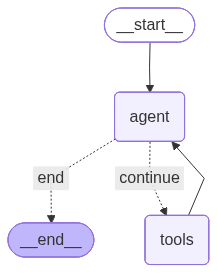

In [32]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 这里需要额外依赖，因此属于可选步骤
    pass

### 注意：有时 Mermaid 在线渲染不可用

这种情况下可以运行：`print(hier.get_graph().draw_ascii())`
或：`print(hier.get_graph().draw_mermaid())`
然后前往 [Mermaid Live Editor](https://mermaid.live/edit#pako:eNp1kmFrgzAQhv9KuMFoQZ3a1bRp6Zf1J-zTliGpJiqkicS4rSv974ux2PXDEOLd8d77HJecodAlBwJhGFJVaCWailCFkJD6q6iZsT5DqOjNJydINoozQ5WXV4a1NXrdb6iiNs876-R5Pnvftrsp2z61u485IUQ0prOD8NCfuJn5cz7kHZfSFcafr7gxrNG-egvnI4SrckL4eAJINvpPaBSGO-Q5m4nrayNqc49CYYQe1aFrN6VWfIxQ5NRXzr9yqXX7R34DjhhPvPWNNm7Wbs8FKrlgvbRINFKSB5GKWIhg2HFY86aqLUmi9K7Bb9HLQ92yorEnEt8Jhi1c7Q7ikImCKgigMk0JRDDZ8QCO3BzZkMN5uFsKtuZHToG48DoQBaourq9l6k3rIxBretdpdF_Vk0_flszyfcPcO7hJ3LK4edG9skCS2FsAOcO3yxY4wqslXiySZJk9JzgL4AQkfY6jeJllGcZr963SSwA_HhpH2TJJsjRe4XWCFyleX34BzNfoqQ)，粘贴 Mermaid 源码以生成图结构。